# Prepare the features

- [X] BOP features arrangement and averagings
- [O] Library Features arrangement ad averaging
  average per polihedra.
  average per structure.
  atoms in each polyhedra.
- [X] Matminer features cleanup (decide min, max or avg)
- clear feature list from correlations
- outlier detection based on features
- Feature Distribution plots

# Included averages

- moments of the total density of states :  

$$ m_0^i = \left( \sum_{j} m_j^i \right)/N_{atoms} $$

- CP averaged moments, norm to total number of atoms:

$$ 
   m_{CP}^i =  \left( \sum_{j \in CP} m_j^i \right)/N_{atoms}
$$ 

- CP averaged moments, norm atoms in CP:

$$ 
   m_{CP}^i =  \left( \sum_{j \in CP} m_j^i \right)/N_{CP}
$$ 

# but I should also include:

- correlation matrices for pair of sets

 - input : features dataframes from prev steps
 - output: clean features dataframes into picles

In [1]:
from Tools.DatasetTools.Commoms import *
from Tools.DatasetTools import GeneralFeaturizer as gf
dataset = 'Fe-Mo' #'Cr-Co-W'
NameForFile = 'FeMo'
descriptorlocation = os.path.join(dataset, 'Descriptors')
system = dataset.replace('-','')
from dependencies.bopfoxfeaturizer.BopFoxFeaturizer.Featurizer import Featurizer
from dependencies.bopfoxfeaturizer.BopFoxFeaturizer.brief_summary_parser import StructSummaryParser
import seaborn as sns
from Tools.DatasetTools.MLConveniences import filter_features
from Tools.PredictionTools.MakeAtomsOjects import make_all_atoms_objects, permutate
import joblib
import pickle

plt.rc('figure', figsize=(18, 8))
plt.rc('font', size=34)
plt.rc('xtick', labelsize=32)
plt.rc('ytick', labelsize=32)
plt.rc('axes', labelsize=34)
from matplotlib.lines import Line2D

In [2]:
plt.rc('text', usetex=True)
plt.rc('font', family='serif', size=12)
plt.rc('xtick', labelsize=12)
plt.rc('ytick', labelsize=12)
plt.rc('axes', labelsize=12)

In [3]:
CNListLocation = os.path.join(descriptorlocation,'CNList.pkl')
CNList = pd.read_pickle(CNListLocation)

In [4]:
binaryr = permutate('R', 2, 11)

In [5]:
atoms_objects_file = os.path.join(dataset,'Atomsobjects/R_structures.pkl')

In [6]:
os.path.exists(atoms_objects_file)

True

In [7]:
if os.path.exists(atoms_objects_file):
    AtomsObjects = pd.read_pickle(atoms_objects_file)
else:
    AtomsObjects = make_all_atoms_objects(binaryr)
    AtomsObjects = AtomsObjects.to_frame()
    AtomsObjects.columns = ['atoms']
    AtomsObjects.to_pickle(atoms_object_file)

In [8]:
RBS = AtomsObjects

In [9]:
RBS['num_atoms'] = RBS.atoms.map(len)

In [10]:
RBS[['Fe', 'Mo']] = pd.DataFrame.from_dict(
    RBS.atoms.map(lambda a: pd.Series(a.symbols).value_counts().to_dict()).to_dict(),
    orient = 'index'
).fillna(0)

# EASY FEATURES 

In [11]:
RBS['Fe_pv'] = RBS['Fe'] / RBS['num_atoms']
RBS['Mo_sv'] = 1 - RBS['Fe_pv']
RBS['Mag'] = 0 #NM
RBS['Structure'] = 4

In [12]:
RBS.index += '.NM'

In [13]:
RBS

,atoms,num_atoms,Fe,Mo,Fe_pv,Mo_sv,Mag,Structure
Fe_pv53.R-AAAAAAAAAAA.NM,"(Atom('Fe', [5.5758179773241885, 5.09570158339...",53,53.0,0.0,1.000000,0.000000,0,4
Fe_pv47Mo_sv6.R-AAAAAAAAAAB.NM,"(Atom('Fe', [5.599079257515289, 5.116959906890...",53,47.0,6.0,0.886792,0.113208,0,4
Fe_pv51Mo_sv2.R-AAAAAAAAABA.NM,"(Atom('Fe', [5.583593282160754, 5.102807380847...",53,51.0,2.0,0.962264,0.037736,0,4
Fe_pv45Mo_sv8.R-AAAAAAAAABB.NM,"(Atom('Fe', [5.606790225019939, 5.124006906896...",53,45.0,8.0,0.849057,0.150943,0,4
Fe_pv47Mo_sv6.R-AAAAAAAABAA.NM,"(Atom('Fe', [5.599079257515289, 5.116959906890...",53,47.0,6.0,0.886792,0.113208,0,4
...,...,...,...,...,...,...,...,...
Fe_pv6Mo_sv47.R-BBBBBBBBABB.NM,"(Atom('Mo', [5.753096403345798, 5.257715113941...",53,6.0,47.0,0.113208,0.886792,0,4
Fe_pv8Mo_sv45.R-BBBBBBBBBAA.NM,"(Atom('Mo', [5.745773392292503, 5.251022664659...",53,8.0,45.0,0.150943,0.849057,0,4
Fe_pv2Mo_sv51.R-BBBBBBBBBAB.NM,"(Atom('Mo', [5.767686757020587, 5.271049137510...",53,2.0,51.0,0.037736,0.962264,0,4
Fe_pv6Mo_sv47.R-BBBBBBBBBBA.NM,"(Atom('Mo', [5.753096403345798, 5.257715113941...",53,6.0,47.0,0.113208,0.886792,0,4


In [14]:
def get_nelem(a):
    return len(np.unique(a.get_chemical_symbols()))

In [15]:
RBS['nelem'] = RBS['atoms'].map(get_nelem)

In [16]:
RBS['nelem']

Fe_pv53.R-AAAAAAAAAAA.NM          1
Fe_pv47Mo_sv6.R-AAAAAAAAAAB.NM    2
Fe_pv51Mo_sv2.R-AAAAAAAAABA.NM    2
Fe_pv45Mo_sv8.R-AAAAAAAAABB.NM    2
Fe_pv47Mo_sv6.R-AAAAAAAABAA.NM    2
                                 ..
Fe_pv6Mo_sv47.R-BBBBBBBBABB.NM    2
Fe_pv8Mo_sv45.R-BBBBBBBBBAA.NM    2
Fe_pv2Mo_sv51.R-BBBBBBBBBAB.NM    2
Fe_pv6Mo_sv47.R-BBBBBBBBBBA.NM    2
Mo_sv53.R-BBBBBBBBBBB.NM          1
Name: nelem, Length: 2048, dtype: int64

##  More R structures

In [17]:
ListOfBriefsumary = [
    'Fe-Mo/data/Fe_pv/briefsummary.dat',
    'Fe-Mo/data/Mo_sv/briefsummary.dat',
    'Fe-Mo/data/Fe_pv-Mo_sv/MoreRsBriefsummary.dat'
]

In [18]:
parser  = StructSummaryParser('Fe-Mo', ListOfBriefsummary=ListOfBriefsumary)#BriefSummary

In [19]:
orig_bs = parser.concat_briefsummaries(ListOfBriefsumary)

In [20]:
Features  = Featurizer(orig_bs)

In [21]:
if 'Fe' in dataset:
    ground_states = Features.get_ground_states_energies(force_mag_phase=('Fe_pv', 'NM', 'fcc'))
else:
    ground_states = Features.get_ground_states_energies()

In [22]:
this_ground_states = {}
if 'Fe' in dataset:
    print('correcting for Fe')
    this_ground_states[('Fe_pv', 'FM')] = ground_states[('Fe_pv', 'FM', 'bcc')]
    this_ground_states[('Fe_pv', 'NM')] = ground_states[('Fe_pv', 'NM', 'hcp')]
if 'Mo' in dataset:
    this_ground_states[('Mo_sv', 'FM')] = ground_states[('Mo_sv', 'FM', 'bcc')]
    this_ground_states[('Mo_sv', 'NM')] = ground_states[('Mo_sv', 'NM', 'bcc')]

correcting for Fe


In [23]:
this_other_ground_states = {}
if 'Fe' in dataset:
    print('correcting for Fe')
    this_other_ground_states[('Fe_pv', 'FM')] = ground_states[('Fe_pv', 'FM', 'bcc')]
    this_other_ground_states[('Fe_pv', 'NM')] = ground_states[('Fe_pv', 'NM', 'fcc')]
if 'Mo' in dataset:
    this_other_ground_states[('Mo_sv', 'FM')] = ground_states[('Mo_sv', 'FM', 'bcc')]
    this_other_ground_states[('Mo_sv', 'NM')] = ground_states[('Mo_sv', 'NM', 'bcc')]

correcting for Fe


In [24]:
orig_bs['EF_fmbcc'] = Features.get_formation_energies(this_ground_states, force_reference_energy={'Fe_pv': ground_states[('Fe_pv', 'FM', 'bcc')]})
orig_bs['EF_nmhcp'] =  Features.get_formation_energies(this_ground_states)
orig_bs['EF_nmfcc'] =  Features.get_formation_energies(this_other_ground_states)

In [25]:
orig_bs.query('index.str.contains("R")')

,,V,E0,B,fit,xc,encut,deltak,ncrash,nelem,...,atom_A,atom_B,num_atom_A,num_atom_B,num_atoms,Fe_pv,Mo_sv,EF_fmbcc,EF_nmhcp,EF_nmfcc
Fe_pv15Mo_sv38.R-AAAABBBBBBB.NM,bulk R-AAAABBBBBBB,14.436090 A,-10.020954,255.953497 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Fe_pv,Mo_sv,15,38,53,0.283019,0.716981,0.155125,0.134967,0.112588
Fe_pv8Mo_sv45.R-BBBBBBBBBAA.NM,bulk R-BBBBBBBBBAA,15.771180 A,-10.065029,228.424823 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Fe_pv,Mo_sv,8,45,53,0.150943,0.849057,0.464878,0.454127,0.442192
Fe_pv6Mo_sv47.R-BBBBBBBBBBA.NM,bulk R-BBBBBBBBBBA,15.923339 A,-10.206694,230.367641 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Fe_pv,Mo_sv,6,47,53,0.113208,0.886792,0.424307,0.416244,0.407293
Fe_pv9Mo_sv44.R-AAABBBBBBBB.NM,bulk R-AAABBBBBBBB,15.195143 A,-10.255394,247.124292 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Fe_pv,Mo_sv,9,44,53,0.169811,0.830189,0.223966,0.211872,0.198445
Fe_pv3Mo_sv50.R-AABBBBBBBBB.NM,bulk R-AABBBBBBBBB,15.948587 A,-10.493489,240.778599 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Fe_pv,Mo_sv,3,50,53,0.056604,0.943396,0.289153,0.285122,0.280646
Fe_pv1Mo_sv52.R-ABBBBBBBBBB.NM,bulk R-ABBBBBBBBBB,16.207674 A,-10.574992,238.852230 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Fe_pv,Mo_sv,1,52,53,0.018868,0.981132,0.308744,0.307400,0.305908
Mo_sv53.R.NM,bulk R,16.315439 A,-10.625314,238.808096 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,1,...,Mo_sv,,53,0,53,0.000000,1.000000,0.308969,0.308969,0.308969
Fe_pv53.R.NM,bulk R,10.496832 A,-8.018508,274.081057 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,1,...,Fe_pv,,53,0,53,1.000000,0.000000,0.236786,0.165561,0.086491
Fe_pv52Mo_sv1.R-BAAAAAAAAAA.NM,bulk R-BAAAAAAAAAA,10.590332 A,-8.076914,273.598211 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Fe_pv,Mo_sv,52,1,53,0.981132,0.018868,0.228927,0.159046,0.081468
Fe_pv51Mo_sv2.R-AAAAAAAAABA.NM,bulk R-AAAAAAAAABA,10.670060 A,-8.146282,274.796406 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Fe_pv,Mo_sv,51,2,53,0.962264,0.037736,0.210106,0.141569,0.065482


# CALCULATE FEATURES AND APPLY CN AVERAGE. THE ATOMS OBJECTS ARE ALREADY ORDERED !

In [26]:
from Tools.DatasetTools.GeneralFeaturizer import cn_persite
cn_persite['R']
for at in  RBS['atoms'][2]:
    print(at)
print(RBS.index[2])

Atom('Fe', [5.583593282160754, 5.102807380847488, 5.555099560384278], index=0)
Atom('Fe', [3.40353342339589, 3.112103794037992, 3.38904591128019], index=1)
Atom('Fe', [7.763653140925616, 7.093510967656983, 7.721153209488368], index=2)
Atom('Fe', [1.9111217335428652, 2.0162836649233804, 6.851198408955685], index=3)
Atom('Fe', [6.855779526133419, 1.5767594813539874, 2.292857577413509], index=4)
Atom('Fe', [2.473943886880756, 6.680704647165757, 2.0341080987140243], index=5)
Atom('Fe', [9.256064830778644, 8.189331096771598, 4.259000711812871], index=6)
Atom('Fe', [4.311407038188091, 8.628855280340987, 8.817341543355047], index=7)
Atom('Fe', [8.693242677440754, 3.5249101145292197, 9.076091022054529], index=8)
Atom('Fe', [2.432968727280905, 4.18035126210633, 7.496463148171309], index=9)
Atom('Fe', [7.4475578529956294, 1.9532439225780034, 4.496678053384418], index=10)
Atom('Fe', [4.687891179042978, 7.182276192693374, 2.499807946289788], index=11)
Atom('Fe', [8.734217837040603, 6.0252634995886

# Load BOP Features 

In [27]:
model = '0.7projections_os'

In [28]:
results_pickle = os.path.join(descriptorlocation, f'Rstructures_FeMo_initial_{model}_table_WUBIND_16.pkl')

In [29]:
R_BOPS = pd.read_pickle(results_pickle)

In [30]:
R_BOPS.index += '.NM'

In [31]:
specialcolumns =['U_bind','U_bond_atom']#, 'U_bond_atom_list'] 
averaged_bop_file = os.path.join(descriptorlocation,'CNAV_'+os.path.basename(results_pickle))

In [32]:
CNList = pd.Series([cn_persite['R']]*len(R_BOPS), index=R_BOPS.index)

In [33]:
featurescnav = {}
if os.path.exists(averaged_bop_file):
    featurescnav[model] = pd.read_pickle(averaged_bop_file).astype(float)  # for some reason some values are objects
else:
    columnstoexpand = R_BOPS.columns.drop(specialcolumns)
    df = gf.array_expansions(R_BOPS, columnstoexpand)
    ThisCoordination = CNList[R_BOPS.index]
    df = gf.featurize_dataframe(df, ThisCoordination)
    shape_factors = gf.get_shape_factors(df)
    featurescnav[model] = pd.concat([R_BOPS[specialcolumns[:-1]], df, shape_factors],  axis=1)
    featurescnav[model].to_pickle(averaged_bop_file)

In [34]:
featurescnav[model].index += '.NM'

In [35]:
RBS.columns

Index(['atoms', 'num_atoms', 'Fe', 'Mo', 'Fe_pv', 'Mo_sv', 'Mag', 'Structure',
       'nelem'],
      dtype='object')

In [36]:
featurescnav[model][['Structure', 'Mag']] = RBS[['Structure', 'Mag']]

# Load ACE features

In [37]:
CNAV_ACE_R_file = os.path.join(descriptorlocation, f'{dataset}-ACE-CNAV-Rs.pkl')

In [38]:
featurescnav['ACE'] = pd.read_pickle(CNAV_ACE_R_file)

In [39]:
featurescnav['ACE'][['Structure', 'Mag']] = RBS[['Structure', 'Mag']]

# LOAD MODELS 

In [40]:
regressor_file = os.path.join(dataset, 'results', f'voting_regressor_KernelRidge.pkl')

In [41]:
voting_regressor = joblib.load(regressor_file)

# Prediction ! 

In [42]:
#combi = ('Kernel Ridge', '0.7 Projections OS BOP')
combi = ('Kernel Ridge', 'ACE')

In [43]:
Prediction_Values_R = pd.Series(voting_regressor[combi].predict(featurescnav[combi[1]]), index=featurescnav[combi[1]].index)

In [44]:
Prediction_Values_R

Fe_pv53.R-AAAAAAAAAAA.NM          0.182670
Fe_pv47Mo_sv6.R-AAAAAAAAAAB.NM    0.078578
Fe_pv51Mo_sv2.R-AAAAAAAAABA.NM    0.138675
Fe_pv45Mo_sv8.R-AAAAAAAAABB.NM    0.051306
Fe_pv47Mo_sv6.R-AAAAAAAABAA.NM    0.133000
                                    ...   
Fe_pv6Mo_sv47.R-BBBBBBBBABB.NM    0.340189
Fe_pv8Mo_sv45.R-BBBBBBBBBAA.NM    0.419544
Fe_pv2Mo_sv51.R-BBBBBBBBBAB.NM    0.337962
Fe_pv6Mo_sv47.R-BBBBBBBBBBA.NM    0.375877
Mo_sv53.R-BBBBBBBBBBB.NM          0.286013
Length: 2048, dtype: float64

In [45]:
bag_of_predictions = []
for name, estimator in voting_regressor[combi].named_estimators_.items():
    this_prediction = pd.Series(estimator.predict(featurescnav['ACE']), index = featurescnav['ACE'].index)
    bag_of_predictions.append(this_prediction)

In [46]:
bag_of_predictions = pd.DataFrame(bag_of_predictions).transpose()

In [47]:
ERR = bag_of_predictions.std(axis=1)

In [48]:
BS = pd.read_pickle('Fe-Mo/FullyCuratedParsedBriefSummary.pkl')

In [49]:
calcs_R = BS[['Fe_pv','EF_nmhcp']].query('index.str.contains("R-")')

Text(0.5, 0, '$\\Delta E_f $(eV/at)')

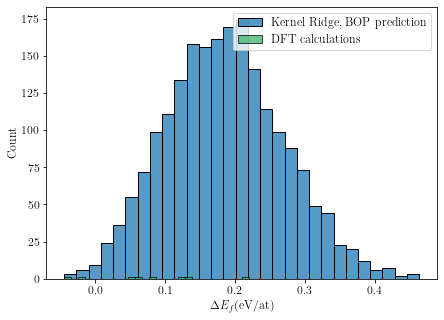

In [52]:
ax = sns.histplot(Prediction_Values_R, label = 'Kernel Ridge, BOP prediction')
ax = sns.histplot(calcs_R['EF_nmhcp'] , label = 'DFT calculations', binrange = [Prediction_Values_R.min(), Prediction_Values_R.max()], bins = 50, color = 'mediumseagreen')
ax.legend()
ax.set_xlabel(r'$\Delta E_f $(eV/at)')

Text(0, 0.5, '$\\Delta E_f$ (eV/atom)')

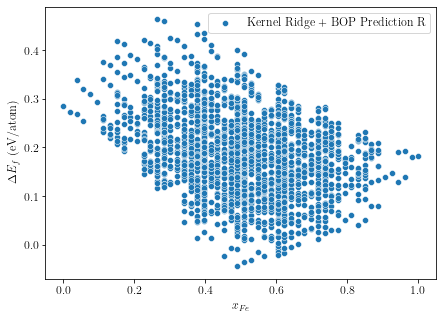

In [53]:
ax = sns.scatterplot(x = RBS['Fe_pv'], y = Prediction_Values_R, label = 'Kernel Ridge + BOP Prediction R')
ax.set_xlabel(r'$x_{Fe}$')
ax.set_ylabel(r'$\Delta E_f$ (eV/atom)')

In [54]:
Prediction_Values_R.to_pickle(os.path.join(dataset, 'results', 'R_structures_Predicted_ACE_EF_nmhcp.pkl'))

In [55]:
RBS['EF_nmhcp'] = Prediction_Values_R

# Recover learning prediction 

In [56]:
ModelName = 'Kernel Ridge'

In [57]:
#orig_bs = pd.read_pickle('Fe-Mo/ParsedBriefsummary.pkl')

In [58]:
orig_bs['Phase'] = orig_bs.index.str.split('.').map(lambda i: i[1]).str.split('-').map(lambda i: i[0])

In [59]:
orig_bs.query('index.str.contains("R")')

,,V,E0,B,fit,xc,encut,deltak,ncrash,nelem,...,atom_B,num_atom_A,num_atom_B,num_atoms,Fe_pv,Mo_sv,EF_fmbcc,EF_nmhcp,EF_nmfcc,Phase
Fe_pv15Mo_sv38.R-AAAABBBBBBB.NM,bulk R-AAAABBBBBBB,14.436090 A,-10.020954,255.953497 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Mo_sv,15,38,53,0.283019,0.716981,0.155125,0.134967,0.112588,R
Fe_pv8Mo_sv45.R-BBBBBBBBBAA.NM,bulk R-BBBBBBBBBAA,15.771180 A,-10.065029,228.424823 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Mo_sv,8,45,53,0.150943,0.849057,0.464878,0.454127,0.442192,R
Fe_pv6Mo_sv47.R-BBBBBBBBBBA.NM,bulk R-BBBBBBBBBBA,15.923339 A,-10.206694,230.367641 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Mo_sv,6,47,53,0.113208,0.886792,0.424307,0.416244,0.407293,R
Fe_pv9Mo_sv44.R-AAABBBBBBBB.NM,bulk R-AAABBBBBBBB,15.195143 A,-10.255394,247.124292 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Mo_sv,9,44,53,0.169811,0.830189,0.223966,0.211872,0.198445,R
Fe_pv3Mo_sv50.R-AABBBBBBBBB.NM,bulk R-AABBBBBBBBB,15.948587 A,-10.493489,240.778599 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Mo_sv,3,50,53,0.056604,0.943396,0.289153,0.285122,0.280646,R
Fe_pv1Mo_sv52.R-ABBBBBBBBBB.NM,bulk R-ABBBBBBBBBB,16.207674 A,-10.574992,238.852230 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Mo_sv,1,52,53,0.018868,0.981132,0.308744,0.307400,0.305908,R
Mo_sv53.R.NM,bulk R,16.315439 A,-10.625314,238.808096 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,1,...,,53,0,53,0.000000,1.000000,0.308969,0.308969,0.308969,R
Fe_pv53.R.NM,bulk R,10.496832 A,-8.018508,274.081057 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,1,...,,53,0,53,1.000000,0.000000,0.236786,0.165561,0.086491,R
Fe_pv52Mo_sv1.R-BAAAAAAAAAA.NM,bulk R-BAAAAAAAAAA,10.590332 A,-8.076914,273.598211 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Mo_sv,52,1,53,0.981132,0.018868,0.228927,0.159046,0.081468,R
Fe_pv51Mo_sv2.R-AAAAAAAAABA.NM,bulk R-AAAAAAAAABA,10.670060 A,-8.146282,274.796406 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Mo_sv,51,2,53,0.962264,0.037736,0.210106,0.141569,0.065482,R


In [60]:
from dependencies.bopfoxfeaturizer.BopFoxFeaturizer.struct_db import struct_db
#struct_db = SourceFileLoader('struct_db','BopFoxFeaturizer/struct_db.py').load_module().struct_db
strucdic = struct_db().strucstrings

Target_Class = pd.Series(
    orig_bs.index.str.split('.').map(lambda l: l[1]).map(lambda s: s.split('-')[0]),
    index=orig_bs.index
)
Target_Class[Target_Class.map(lambda s: s in strucdic['list.hcp'])]='hcp'
Target_Class[Target_Class.map(lambda s: s in strucdic['list.fcc'])]='fcc'
Target_Class[Target_Class.map(lambda s: s in strucdic['list.bcc'])]='bcc'

In [61]:
orig_bs['Phase'] = Target_Class

I have a problem with one point 

In [62]:
#orig_bs = orig_bs.query('abs(Fe_pv - 0.72)>0.1')

In [63]:
OrigPhaseBS =  {
    '': {'DFT R':  orig_bs.query('Phase == "R"')}
}

In [64]:
OrigPhaseBS['']['DFT R']

,,V,E0,B,fit,xc,encut,deltak,ncrash,nelem,...,atom_B,num_atom_A,num_atom_B,num_atoms,Fe_pv,Mo_sv,EF_fmbcc,EF_nmhcp,EF_nmfcc,Phase
Fe_pv15Mo_sv38.R-AAAABBBBBBB.NM,bulk R-AAAABBBBBBB,14.436090 A,-10.020954,255.953497 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Mo_sv,15,38,53,0.283019,0.716981,0.155125,0.134967,0.112588,R
Fe_pv8Mo_sv45.R-BBBBBBBBBAA.NM,bulk R-BBBBBBBBBAA,15.771180 A,-10.065029,228.424823 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Mo_sv,8,45,53,0.150943,0.849057,0.464878,0.454127,0.442192,R
Fe_pv6Mo_sv47.R-BBBBBBBBBBA.NM,bulk R-BBBBBBBBBBA,15.923339 A,-10.206694,230.367641 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Mo_sv,6,47,53,0.113208,0.886792,0.424307,0.416244,0.407293,R
Fe_pv9Mo_sv44.R-AAABBBBBBBB.NM,bulk R-AAABBBBBBBB,15.195143 A,-10.255394,247.124292 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Mo_sv,9,44,53,0.169811,0.830189,0.223966,0.211872,0.198445,R
Fe_pv3Mo_sv50.R-AABBBBBBBBB.NM,bulk R-AABBBBBBBBB,15.948587 A,-10.493489,240.778599 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Mo_sv,3,50,53,0.056604,0.943396,0.289153,0.285122,0.280646,R
Fe_pv1Mo_sv52.R-ABBBBBBBBBB.NM,bulk R-ABBBBBBBBBB,16.207674 A,-10.574992,238.852230 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Mo_sv,1,52,53,0.018868,0.981132,0.308744,0.307400,0.305908,R
Mo_sv53.R.NM,bulk R,16.315439 A,-10.625314,238.808096 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,1,...,,53,0,53,0.000000,1.000000,0.308969,0.308969,0.308969,R
Fe_pv53.R.NM,bulk R,10.496832 A,-8.018508,274.081057 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,1,...,,53,0,53,1.000000,0.000000,0.236786,0.165561,0.086491,R
Fe_pv52Mo_sv1.R-BAAAAAAAAAA.NM,bulk R-BAAAAAAAAAA,10.590332 A,-8.076914,273.598211 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Mo_sv,52,1,53,0.981132,0.018868,0.228927,0.159046,0.081468,R
Fe_pv51Mo_sv2.R-AAAAAAAAABA.NM,bulk R-AAAAAAAAABA,10.670060 A,-8.146282,274.796406 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Mo_sv,51,2,53,0.962264,0.037736,0.210106,0.141569,0.065482,R


# New Convex Hulls 

In [65]:
from Tools.DatasetTools.Tools import Plotting, PlottingChulls
P = Plotting()

In [66]:
target_case = 'EF_nmhcp'

In [67]:
from scipy.spatial import ConvexHull

In [68]:
points = RBS[['Fe_pv', 'EF_nmhcp']]

In [69]:
PhasesBS = {'': {'R' : RBS}}

In [70]:
from scipy.spatial import QhullError
def plot_chull(
    thePhasesBS,
    theproperty, 
    mag_list = None,
    plot_points = True,
    plot_only = [], 
    line_styles = '-',
    fig_= None,
    ax_ = None,
    components = ['Fe_pv', 'Mo_sv'], 
    palettename = 'tab20c'
):
    for mag, PhaseBS in  thePhasesBS.items():
        if mag not in mag_list:
            continue
        if len(plot_only) == 0:
            plot_only = PhaseBS.keys()
        points = P.get_x_ef_points(PhaseBS, components, property=theproperty)
        chulls =  P.get_convex_hulls(PhaseBS, components, getproperty = theproperty, return_points = False)
        palette = PlottingChulls.make_palette_forlist(plot_only, palette_name=palettename)
        if len(plot_only)>0:
            palette = {name: color for name, color in palette.items() if name in plot_only} 
        if ax_ is None:
            fig_,  ax_ = plt.subplots()#figsize=(12,10)
            handles = []
            labels = []
        else:
            handles, labels = ax_.get_legend_handles_labels()
#        fig = figs_mag[mag]
#        ax = ax_mag[mag]
        for phase, chull in chulls.items():
            if len(plot_only) > 0:
                if phase not in plot_only:
                    continue
            for visible_facet in chull.simplices[chull.good]:
                l = ax_.plot(chull.points[visible_facet,0], chull.points[visible_facet,1],line_styles,  color=palette[phase], linewidth = 1, markersize=2, markeredgecolor='k')
                if plot_points:
                    l = ax_.plot(points[phase][components[0]] , points[phase][theproperty], 'o', color = palette[phase], markersize=2)
            handles.append(l[0])
            labels.append(phase)
        leg = ax_.legend(handles, labels, bbox_to_anchor=(1.01,1), title=mag)
        setlw = [ha.set_linewidth(5) for ha in leg.get_lines() ]
        ax_.set_ylabel(r'$\Delta E _f$ (eV/atom)')
        ax_.set_xlabel(rf'$x_{{{components[0]}}}$')
        fig_.tight_layout()
    return fig_, ax_

In [71]:
from matplotlib.lines import Line2D

In [72]:
palette1 = PlottingChulls.make_palette_forlist(['R'])
palette2 = PlottingChulls.make_palette_forlist(['R'], palette_name='copper')

In [73]:
L1 = Line2D([0],[0], marker = 'o', color=palette1['R'], markersize = 1, linewidth = 2)
L2 = Line2D([0],[0], marker = 'o', color=palette2['R'], markersize = 1, linewidth = 2 )

In [74]:
chulls= P.get_convex_hulls(PhasesBS[''],components=['Fe_pv', 'Mo_sv'],
                           viewpoint=[0.5, -10], getproperty='EF_nmhcp')

In [75]:
good_vertices = np.unique(chulls['R'].simplices[chulls['R'].good].ravel())

In [76]:
stds = bag_of_predictions.iloc[good_vertices].std(axis=1)

In [77]:
errs = pd.concat([stds, PhasesBS['']['R'][['Fe_pv', 'EF_nmhcp']].loc[stds.index]], axis = 1 )

In [78]:
errs.rename(columns={0: 'std'}, inplace=True)

In [79]:
errs.sort_values(by='Fe_pv', inplace=True)

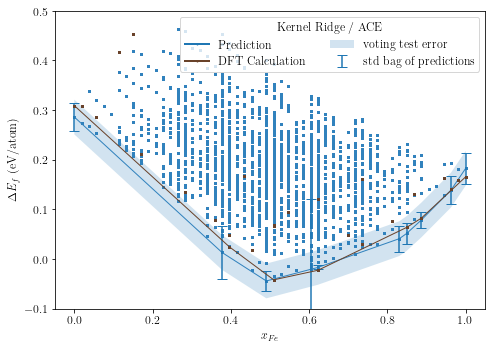

In [80]:
tfig, tax = plot_chull(PhasesBS, 'EF_nmhcp', mag_list=[''], plot_points=True, fig_ = None, ax_=None)
e = tax.errorbar(PhasesBS['']['R']['Fe_pv'][stds.index],PhasesBS['']['R']['EF_nmhcp'][stds.index],
             yerr=stds, capsize=5, fmt='none')
a = tax.fill_between(errs['Fe_pv'], errs['EF_nmhcp']+0.035, errs['EF_nmhcp']-0.035, alpha = 0.2, label='voting test error')
tfig, tax = plot_chull(OrigPhaseBS,
           'EF_nmhcp',
           mag_list=[''], 
           plot_points=True,
           fig_=tfig,
           ax_=tax, palettename='copper')
tax.set_xlabel(r'$x_{Fe}$')
tax.legend(
    [L1, L2, a, e],
    ['Prediction', 'DFT Calculation', 'voting test error', 'std bag of predictions'],
    ncol = 2,
    loc = 'upper right',
    title = 'Kernel Ridge / ACE'
)
tax.set_ylim([-0.1, 0.5])
file_name = os.path.join('Fe-Mo/graphs/R_structure_pred_vs_dft_Kernel Ridge_ACE.pdf')
tfig.tight_layout()
tfig.savefig(file_name)

In [82]:
BS

,,V,E0,B,fit,xc,encut,deltak,ncrash,nelem,...,atom_B,num_atom_A,num_atom_B,num_atoms,Fe_pv,Mo_sv,EF_nmhcp,EF_nmfcc,EF_fmbcc,Phase
Fe_pv8Mo_sv22.sigma-BBABB.FM,bulk sigma-BBABB.FM,14.954763 A,-10.004507,224.285410 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Mo_sv,8,22,30,0.266667,0.733333,0.215355,0.215355,0.215355,sigma
Fe_pv10Mo_sv20.sigma-ABBAB.FM,bulk sigma-ABBAB.FM,14.130625 A,-10.006896,237.907324 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Mo_sv,10,20,30,0.333333,0.666667,0.034369,0.034369,0.034369,sigma
Fe_pv4Mo_sv20.C36-ABBBB.FM,bulk C36-ABBBB.FM,16.270923 A,-10.007837,204.470374 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Mo_sv,4,20,24,0.166667,0.833333,0.479921,0.479921,0.479921,C36
Fe_pv5Mo_sv24.chi-AABB.FM,bulk chi-AABB.FM,15.751001 A,-10.015010,216.183583 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Mo_sv,5,24,29,0.172414,0.827586,0.457352,0.457352,0.457352,chi
Fe_pv15Mo_sv38.R-AAAABBBBBBB.NM,bulk R-AAAABBBBBBB,14.436090 A,-10.020954,255.953497 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Mo_sv,15,38,53,0.283019,0.716981,0.134967,0.112588,0.155125,R
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Fe_pv3Mo_sv10.mu-ABBBA.NM,bulk mu-ABBBA,15.125643 A,-9.973264,240.020984 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Mo_sv,3,10,13,0.230769,0.769231,0.326354,0.308107,0.342791,mu
Fe_pv8Mo_sv22.sigma-BBABB.NM,bulk sigma-BBABB,14.698886 A,-9.976143,247.238692 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Mo_sv,8,22,30,0.266667,0.733333,0.224750,0.203664,0.243743,sigma
Fe_pv1Mo_sv3.L12-AB3.FM,bulk L12-AB3.FM,14.806728 A,-9.986411,223.435464 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Mo_sv,1,3,4,0.250000,0.750000,0.278101,0.278101,0.278101,fcc
Fe_pv8Mo_sv22.sigma-BBBBA.FM,bulk sigma-BBBBA.FM,15.095159 A,-9.991080,207.683558 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Mo_sv,8,22,30,0.266667,0.733333,0.228782,0.228782,0.228782,sigma


# Comparision for the other phases 

In [126]:
def get_bs_byphase(theBS):
    verts = {}
    chulls = {}
    phasepoints = {}
    return {mag: {phase: theBS[(theBS.Phase == phase) & theBS.index.str.contains(mag)] for phase in theBS.Phase.unique()} for mag in ['FM', 'NM', '']}

In [127]:
orig_bs = orig_bs.loc[~orig_bs.index.str.contains('delta')]

In [128]:
OrigPhaseBS = get_bs_byphase(orig_bs)

In [85]:
predictedBS = pd.read_pickle('Fe-Mo/results/Fe-Mo_Kernel Ridge_PredictedBS.pkl')

In [86]:
predictedPhaseBS = get_bs_byphase(predictedBS)

In [87]:
plot_only = ['bcc', 'C14', 'sigma', 'mu', 'C36', 'A15', 'hcp']

In [88]:
dataset

'Fe-Mo'

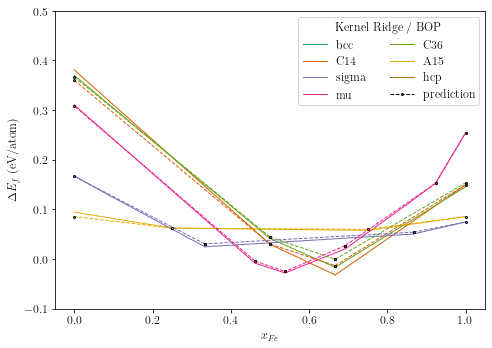

In [89]:
FeatureName = '0.7 Projections OS BOP'
ModelName = 'Kernel Ridge'
palettename = 'Dark2'
fig, ax = plot_chull(
    predictedPhaseBS, theproperty='EF_nmhcp', mag_list=[''], 
           components= [ 'Fe_pv', 'Mo'], plot_points = False,
    plot_only=plot_only, palettename=palettename
)

fig, ax = plot_chull(
    predictedPhaseBS, theproperty=f'EF_nmhcp_{FeatureName}', mag_list=[''], 
           components= [ 'Fe_pv', 'Mo'], plot_points = False,
    plot_only=plot_only, palettename=palettename, line_styles = '--o', fig_ = fig, ax_ = ax
)

ax.set_ylim([-0.1, 0.5])
palette = PlottingChulls.make_palette_forlist(plot_only, palette_name=palettename)
L = []
label = []
for name, color in palette.items():
    L.append(Line2D([0], [0], color = color, lw = 1))
    label.append(name)
L.append(Line2D([0, 1],[0, 0], linestyle = '--', marker = 'o', color='k', linewidth=1, markersize=2))
label.append('prediction')
leg = ax.legend(L, label, loc = 'upper right', ncol =2, scatterpoints=2,  title='Kernel Ridge / BOP')
ax.set_xlabel(r'$x_{Fe}$')
modelforfile=ModelName.replace(' ', '')
featureforfile=FeatureName.replace(' ', '')
fig.tight_layout()
file_name =os.path.join(dataset, 'graphs', f'{dataset}_CompareCHull_{modelforfile}_{featureforfile}.pdf')
fig.savefig(file_name)

#figsize CH  for DFT calculations full

In [90]:
plot_only = plot_only + ['R']

In [91]:
palette = PlottingChulls.make_palette_forlist(plot_only, palette_name=palettename)

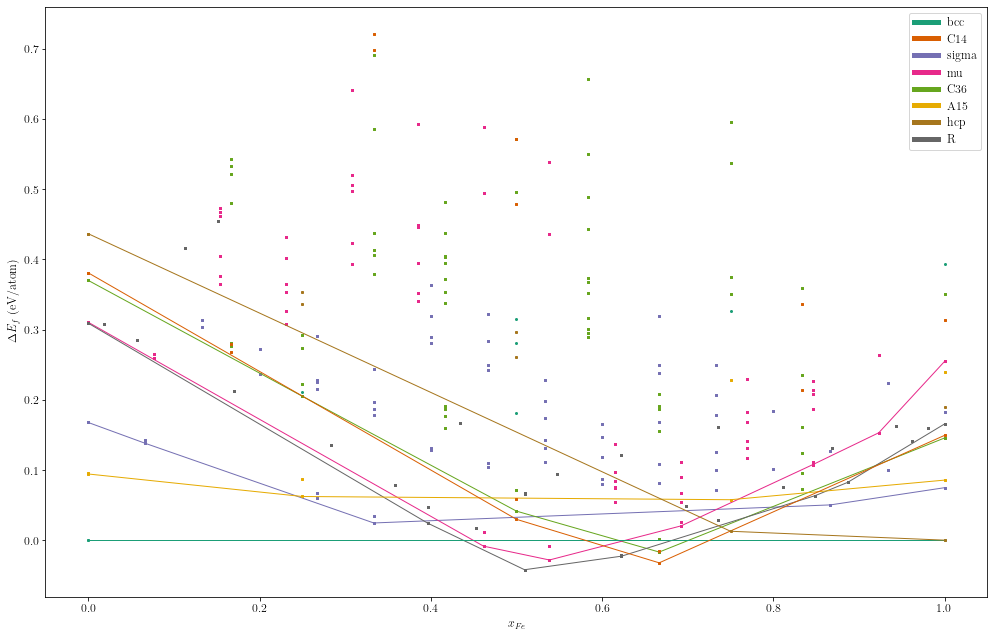

In [92]:
fig, ax = plt.subplots(figsize=(14,9))
fig, ax = plot_chull(
    OrigPhaseBS, theproperty='EF_nmhcp', mag_list=[''], palettename='Dark2', 
    plot_only=plot_only, fig_=fig, ax_ = ax
)
lines = []
labels = []
for name, color in palette.items():
    lines.append(Line2D([0],[0],linewidth = 5, color=color))
    labels.append(name)
ax.legend(lines, labels)
ax.set_xlabel(r'$x_{Fe}$')
filename = os.path.join(dataset, 'graphs', f'{dataset}_ConvexHulls.pdf')
fig.savefig(filename)

In [93]:
OrigPhaseBS['']['C36']

,,V,E0,B,fit,xc,encut,deltak,ncrash,nelem,...,atom_B,num_atom_A,num_atom_B,num_atoms,Fe_pv,Mo_sv,EF_fmbcc,EF_nmhcp,EF_nmfcc,Phase
Fe_pv4Mo_sv20.C36-ABBBB.FM,bulk C36-ABBBB.FM,16.270923 A,-10.007837,204.470374 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Mo_sv,4,20,24,0.166667,0.833333,0.479921,0.479921,0.479921,C36
Fe_pv6Mo_sv18.C36-BBBBA.NM,bulk C36-BBBBA,14.799758 A,-10.041761,250.226688 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Mo_sv,6,18,24,0.250000,0.750000,0.222775,0.204969,0.185201,C36
Fe_pv6Mo_sv18.C36-BBBBA.FM,bulk C36-BBBBA.FM,14.799395 A,-10.041762,250.292861 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Mo_sv,6,18,24,0.250000,0.750000,0.222750,0.222750,0.222750,C36
Fe_pv4Mo_sv20.C36-BBABB.NM,bulk C36-BBABB,15.332601 A,-10.199552,244.204522 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Mo_sv,4,20,24,0.166667,0.833333,0.288233,0.276362,0.263184,C36
Fe_pv4Mo_sv20.C36-BBABB.FM,bulk C36-BBABB.FM,15.414624 A,-10.206763,226.226871 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Mo_sv,4,20,24,0.166667,0.833333,0.280995,0.280995,0.280995,C36
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Fe_pv4Mo_sv20.C36-ABBBB.NM,bulk C36-ABBBB,15.973885 A,-9.933449,220.307395 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Mo_sv,4,20,24,0.166667,0.833333,0.554336,0.542465,0.529287,C36
Fe_pv4Mo_sv20.C36-BABBB.FM,bulk C36-BABBB.FM,15.876718 A,-9.954729,221.227451 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Mo_sv,4,20,24,0.166667,0.833333,0.533029,0.533029,0.533029,C36
Fe_pv4Mo_sv20.C36-BABBB.NM,bulk C36-BABBB,15.876893 A,-9.954733,221.313800 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Mo_sv,4,20,24,0.166667,0.833333,0.533052,0.521181,0.508003,C36
Fe_pv6Mo_sv18.C36-BBBAB.NM,bulk C36-BBBAB,14.873806 A,-9.972833,245.310135 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Mo_sv,6,18,24,0.250000,0.750000,0.291703,0.273897,0.254129,C36


# Bopxplots 

In [94]:
equals = RBS.index.intersection(calcs_R.index)

In [95]:
alldata = pd.concat([RBS['Fe_pv'] , bag_of_predictions], axis = 1).loc[equals]

In [96]:
melted = alldata.melt(id_vars='Fe_pv')

<AxesSubplot:xlabel='Fe_pv', ylabel='value'>

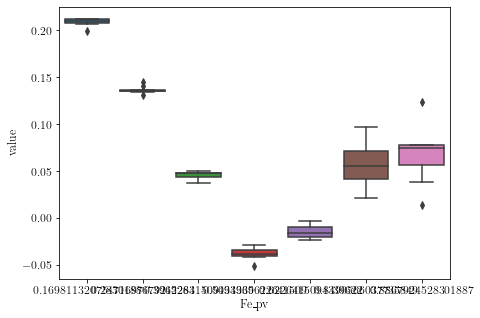

In [97]:
sns.boxplot(data=melted, x= 'Fe_pv', y = 'value')

In [98]:
alldata = alldata.loc[equals].melt(id_vars=['Fe_pv'])

In [99]:
sns.scatterplot(alldata

SyntaxError: unexpected EOF while parsing (400976186.py, line 1)

In [ ]:
ax = sns.scatterplot(x = RBS['Fe_pv'][equals], y = Prediction[equals], label = 'Prediction for R')
sns.scatterplot(data = calcs_R, x = 'Fe_pv', y = 'EF_nmhcp', ax = ax, ls='--', err=ERR[equals])
ax.set_xlabel(r'$x_{Fe}$')
ax.set_ylabel(r'$\Delta E_f$ (eV/atom)')

In [ ]:
ax = sns.scatterplot()